# Does portfolio construction earn its complexity?

## Summary

In January 2025–17 September 2026, HRP minus its prior-risk-scaled equal-weight control has a net annualized mean/volatility difference of **+0.649**, with paired 95% block interval **[-0.649, +1.954]**. This does not establish incremental risk-adjusted value under this universe, zero cash interest and cost assumptions.

## Context and methods

# From an allocation formula to an investable accounting experiment

A covariance estimator does not earn a return. Holdings earn returns, trade, pay costs and
drift. This distinction determines the experiment: all estimators feed the same engine, and
simple controls share dates, information and trading assumptions.

## Inputs and information

SPY, IEMG, TLT, GLD and SHY give a compact equity, emerging-equity, long-rate, gold and
short-rate universe. They were chosen for interpretable exposures, not inferred optimality.
AGG appears only in the contextual 60/40. SHY is a bond fund with rate risk; residual cash
instead earns an explicit assumed zero return. The source register describes revised adjusted
prices. These do not supply historical order books, delisting outcomes or a point-in-time
universe.

Let r_t be the vector of simple daily returns, and Sigma the covariance of the previous 252
returns. Equal weight uses 1/N. Inverse volatility uses weights proportional to 1/sigma_i.
ERC solves min_x .5 x' Sigma x - sum(log x_i), then normalizes x; its first-order conditions
equalize x_i (Sigma x)_i. This explains the independent diagonal-covariance test.

HRP first converts correlations to distances sqrt((1-rho)/2). SciPy needs a condensed
pairwise-distance vector; a square array means observations. After single-linkage ordering,
recursive bisection assigns each child inversely to its inverse-variance-weighted cluster
variance. The two-asset case reduces to inverse variance, not inverse volatility. A tiny
relative diagonal regularization stabilizes semidefinite samples. Failures are reported.

## Exposure versus construction

For each estimated strategy w, a control scales equal weight q by
min(1, sqrt(w' Sigma w / (q' Sigma q))). This uses only prior information and leaves residual
cash. It approximately matches forecast risk, not realized future risk. Low volatility caused
by SHY concentration must not be sold as a universally better covariance model.

The separate defensive rule uses compounded 21/63/126/252-session price momentum. The
legacy code divided daily returns by older daily returns; that is a different quantity and
could explode near zero. The new rule is explicitly a limited VAA-inspired adaptation.

## Timing and accounting

At the first session's close, trade targets computed through the previous close. Old holdings
earn that session; new weights first earn the following close-to-close return. Pretrade weights
u_i = w_i (1+r_i)/(1+w'r). For cost rate a, solve c=a sum |(1-c) target_i-u_i|.
Both sides of a rotation pay; a full switch can trade almost twice NAV. Cash is residual, so
there is no hidden borrowing or uncharged cash trade. Costs are illustrative, not measured spreads.

A hand calculation begins with 1 cash and a 1% per-side rate. Entry costs .01/1.01. After a
10% gain in the first asset, a complete switch costs .02/1.01 of pretrade NAV. Remaining NAV is
10890/10201 = 1.0675423978. The unit test checks this independently of the engine loop.

## Reading the evidence

The late segment is January 2025–17 September 2026 (partial September); all strategies share
428 sessions. Bootstrap intervals pair identical blocks across strategies. They measure
conditional path uncertainty, not the uncertainty of selecting this universe or refitting the
entire procedure. Full-history and 2022 outcomes are descriptive checks. No variant replaces
the primary after inspection. [Results and implications](docs/02-results.md) · [Exact protocol](research/PROTOCOL.md).


### Recompute from pinned inputs

Runs the maintained pipeline, reusing matching checkpoints where available. No notebook-only model logic.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Markdown, Image
from research.run_study import main
from research.common import ROOT, RESULTS, FIGURES
main()

In January 2025–17 September 2026, HRP minus its prior-risk-scaled equal-weight control has a net annualized mean/volatility difference of **+0.649**, with paired 95% block interval **[-0.649, +1.954]**. This does not establish incremental risk-adjusted value under this universe, zero cash interest and cost assumptions.


## Data

Input provenance records the exact vintage or the explicitly illustrative fixture. Retrieval dates do not imply historical availability.

In [2]:
manifest = json.loads((ROOT / "research/data/input_manifest.json").read_text())
display(Markdown("Input kind: **" + manifest.get("kind", "observed adjusted-close snapshots") + "**"))
sources = pd.DataFrame(manifest.get("snapshots", manifest.get("inputs", [])))
columns = [c for c in ["ticker", "rows", "first_date", "last_date", "path"] if c in sources]
display(sources[columns].head(10))

Input kind: **observed adjusted-close snapshots**

,ticker,rows,first_date,last_date
0,SPY,2064,2018-07-02,2026-09-17
1,IEMG,2064,2018-07-02,2026-09-17
2,TLT,2064,2018-07-02,2026-09-17
3,GLD,2064,2018-07-02,2026-09-17
4,SHY,2064,2018-07-02,2026-09-17
5,AGG,2064,2018-07-02,2026-09-17


## Results

In [3]:
import re
text = (ROOT / "docs/02-results.md").read_text()
text = re.sub(r"!\[[^\]]*\]\([^)]*\)", "", text)
display(Markdown(text.replace("../research/", "research/").replace("(01-methods.md)", "(docs/01-methods.md)")))

# Does portfolio construction earn its complexity?

In January 2025–17 September 2026, HRP minus its prior-risk-scaled equal-weight control has a net annualized mean/volatility difference of **+0.649**, with paired 95% block interval **[-0.649, +1.954]**. This does not establish incremental risk-adjusted value under this universe, zero cash interest and cost assumptions.

This is a retrospective ETF study. Cash-heavy risk portfolios can look safer simply because they hold SHY or reduce exposure. The matched-risk control uses only past covariance, with a cap at 100%; realized risks need not match. A mean/volatility ratio with zero assumed cash interest is not an observed risk-free-adjusted Sharpe ratio.

## Late-segment comparison

| strategy | cagr | volatility | max_drawdown | annual_turnover | mean_cash |
| --- | --- | --- | --- | --- | --- |
| 60/40 context | 0.121685 | 0.106896 | -0.112452 | 0.158916 | 0 |
| Defensive momentum | 0.0155946 | 0.0678281 | -0.100231 | 9.43665 | 0 |
| EQ risk ERC | 0.0631003 | 0.0388663 | -0.0287602 | 0.268061 | 0.638605 |
| EQ risk HRP | 0.03123 | 0.0189566 | -0.0142771 | 0.132893 | 0.822514 |
| EQ risk Inverse vol | 0.0651788 | 0.0395678 | -0.0286638 | 0.230299 | 0.62954 |
| ERC | 0.0735657 | 0.0377768 | -0.0256551 | 0.390153 | 0 |
| Equal weight | 0.175443 | 0.108417 | -0.0792407 | 0.311087 | 0 |
| HRP | 0.0357752 | 0.0154672 | -0.0103531 | 0.0666061 | 0 |
| Inverse vol | 0.0760606 | 0.0383892 | -0.0276876 | 0.305928 | 0 |

Returns and risks are decimal annual rates; drawdowns are fractions. Turnover includes buys and sells.



## What changes the answer

| variant | ratio_difference | annual_mean_difference | vol_difference |
| --- | --- | --- | --- |
| primary | 0.648643 | 0.00433863 | -0.00348942 |
| lookback126 | 0.602394 | 0.00551378 | -0.00226649 |
| lookback504 | 0.736922 | -0.000347644 | -0.00719516 |
| shrinkage | 0.269455 | -0.021372 | -0.0182346 |
| cost0 | 0.647346 | 0.00430549 | -0.00348925 |
| cost10 | 0.649942 | 0.00437179 | -0.00348961 |
| extra_session_lag | 0.656365 | 0.00437256 | -0.00353865 |

All variants remain visible; no winning replacement is selected. These comparisons reuse the same history and are not independent trials. The defensive momentum adaptation is separate from covariance estimation, and the 60/40 portfolio is contextual because its universe differs.

## Economic boundary

| strategy | control | annual_gross_headroom_bps | lower95_bps | upper95_bps | annual_incremental_turnover | linear_cost_ceiling_bps_per_dollar |
| --- | --- | --- | --- | --- | --- | --- |
| HRP | EQ risk HRP | 43.0549 | -147.598 | 254.24 | -0.0662871 | — |
| ERC | EQ risk ERC | 98.1822 | -12.6565 | 218.695 | 0.122092 | 804.166 |
| Inverse vol | EQ risk Inverse vol | 101.59 | -9.07145 | 224.982 | 0.0756284 | 1343.28 |

The annual headroom is a gross incremental constant-cost budget, not an observed fee. The per-dollar ceiling is a first-order approximation only when extra turnover is positive. Negative headroom is retained. ERC fallback occurred 0 times over 74 rebalances.

A stronger conclusion needs a prospectively fixed universe, an uninspected sample, observed cash yields and executable spread/size evidence. Adjusted prices may be revised, distributions are reinvested by proxy, closing fractional fills are assumed, and the study does not reconstruct delistings. See [protocol](research/PROTOCOL.md), [inputs and methods](docs/01-methods.md), [source register](research/SOURCES.md), and [next experiment](research/RESEARCH_AGENDA.md).


### Performance

In [4]:
display(pd.read_csv(RESULTS / "performance.csv").round(6).head(30))

,period,strategy,n,annual_mean,cagr,volatility,mean_over_vol_rf0,max_drawdown,terminal_wealth,gross_mean,annual_turnover,annual_cost_fraction,mean_cash,mean_concentration
0,full,60/40 context,1539,0.096481,0.095000,0.106944,0.902164,-0.207264,1.740633,0.096656,0.349444,0.000175,0.000650,0.521123
1,full,Defensive momentum,1539,0.005222,0.003378,0.060782,0.085913,-0.158712,1.020811,0.009750,9.025601,0.004513,0.000650,0.774891
2,full,EQ risk ERC,1539,0.029791,0.029431,0.039594,0.752412,-0.088626,1.193805,0.029933,0.283631,0.000142,0.609900,0.431819
3,full,EQ risk HRP,1539,0.015911,0.015830,0.020241,0.786082,-0.043287,1.100669,0.015998,0.173256,0.000087,0.801672,0.661067
4,full,EQ risk Inverse vol,1539,0.030515,0.030204,0.038908,0.784286,-0.083677,1.199292,0.030649,0.268766,0.000134,0.613674,0.433659
5,full,ERC,1539,0.032353,0.032028,0.040647,0.795951,-0.114515,1.212316,0.032613,0.520179,0.000260,0.000650,0.551887
6,full,Equal weight,1539,0.070193,0.067877,0.095026,0.738675,-0.210006,1.493426,0.070419,0.449925,0.000225,0.000650,0.200629
7,full,HRP,1539,0.017152,0.017083,0.020613,0.832088,-0.064234,1.108989,0.017286,0.269045,0.000135,0.000650,0.919382
8,full,Inverse vol,1539,0.033115,0.032848,0.039845,0.831102,-0.109127,1.218212,0.033357,0.482912,0.000241,0.000650,0.557381
9,late,60/40 context,428,0.120532,0.121685,0.106896,1.127570,-0.112452,1.215350,0.120612,0.158916,0.000079,0.000000,0.520585


### Paired intervals

In [5]:
display(pd.read_csv(RESULTS / "paired_intervals.csv").round(6).head(30))

,strategy,control,metric,estimate,lower95,upper95,block,draws,n
0,HRP,Equal weight,mean_over_vol_rf0,0.734920,-0.690691,2.193720,5,2000,428
1,HRP,Equal weight,mean_over_vol_rf0,0.734920,-0.457782,1.966739,21,2000,428
2,HRP,Equal weight,mean_over_vol_rf0,0.734920,-0.242944,1.684182,63,2000,428
3,HRP,EQ risk HRP,mean_over_vol_rf0,0.648643,-0.884210,2.150513,5,2000,428
4,HRP,EQ risk HRP,mean_over_vol_rf0,0.648643,-0.649224,1.954114,21,2000,428
5,HRP,EQ risk HRP,mean_over_vol_rf0,0.648643,-0.418153,1.709005,63,2000,428
6,ERC,Equal weight,mean_over_vol_rf0,0.352656,-0.062162,0.776786,5,2000,428
7,ERC,Equal weight,mean_over_vol_rf0,0.352656,0.029547,0.677368,21,2000,428
8,ERC,Equal weight,mean_over_vol_rf0,0.352656,0.084712,0.595155,63,2000,428
9,ERC,EQ risk ERC,mean_over_vol_rf0,0.304252,-0.113248,0.709041,5,2000,428


### Implementation

In [6]:
display(pd.read_csv(RESULTS / "implementation.csv").round(6).head(30))

,rebalances,erc_fallbacks,max_cov_condition,cap_Inverse vol,cap_ERC,cap_HRP
0,74,0,5107.17118,0.0,0.0,0.0


### Cost headroom

In [7]:
display(pd.read_csv(RESULTS / "cost_headroom.csv").round(6).head(30))

,strategy,control,annual_gross_headroom_bps,lower95_bps,upper95_bps,annual_incremental_turnover,linear_cost_ceiling_bps_per_dollar
0,HRP,EQ risk HRP,43.054911,-147.597938,254.240406,-0.066287,NaN
1,ERC,EQ risk ERC,98.182157,-12.656483,218.695410,0.122092,804.165667
2,Inverse vol,EQ risk Inverse vol,101.590056,-9.071452,224.981683,0.075628,1343.278672


### Wealth

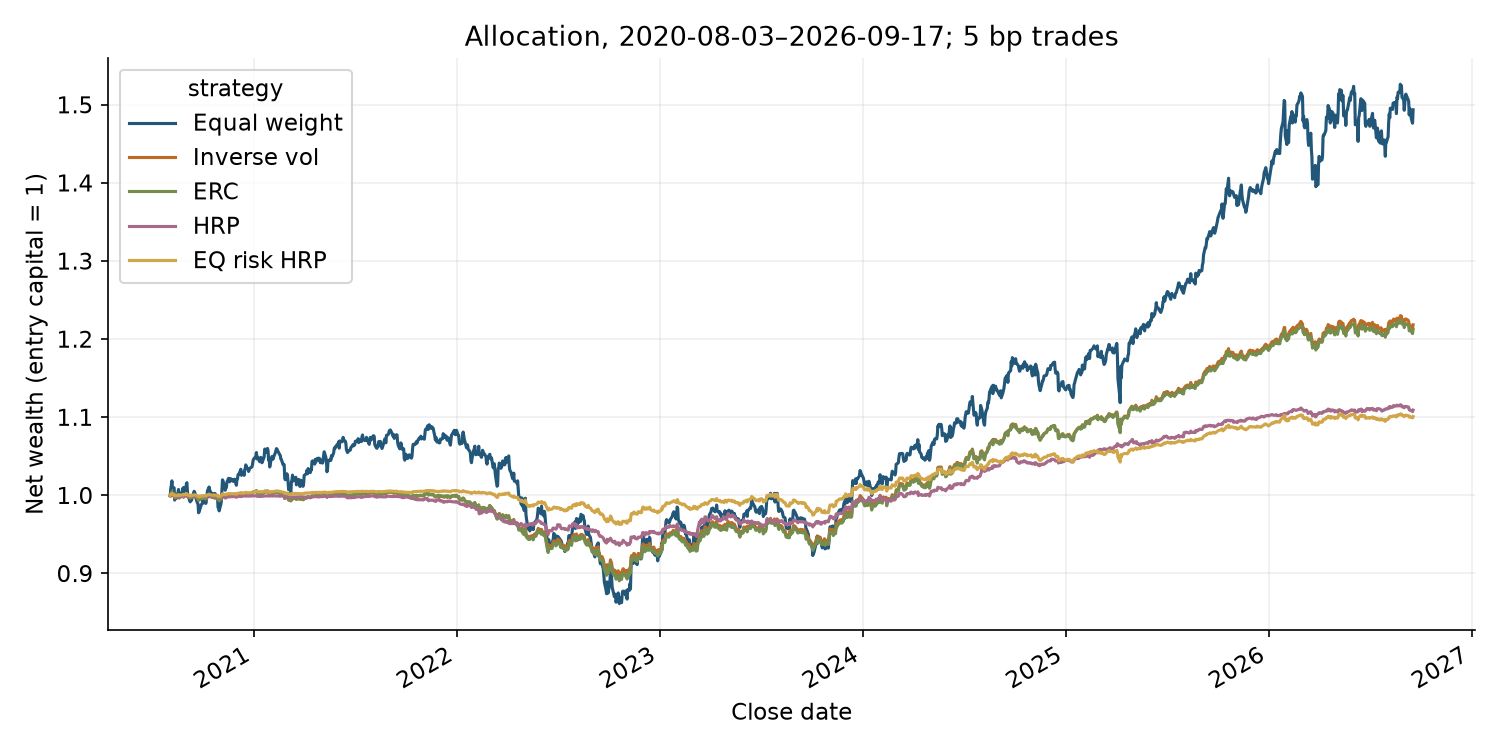

In [8]:
display(Image(filename=str(FIGURES / "wealth.png")))

### Drawdown

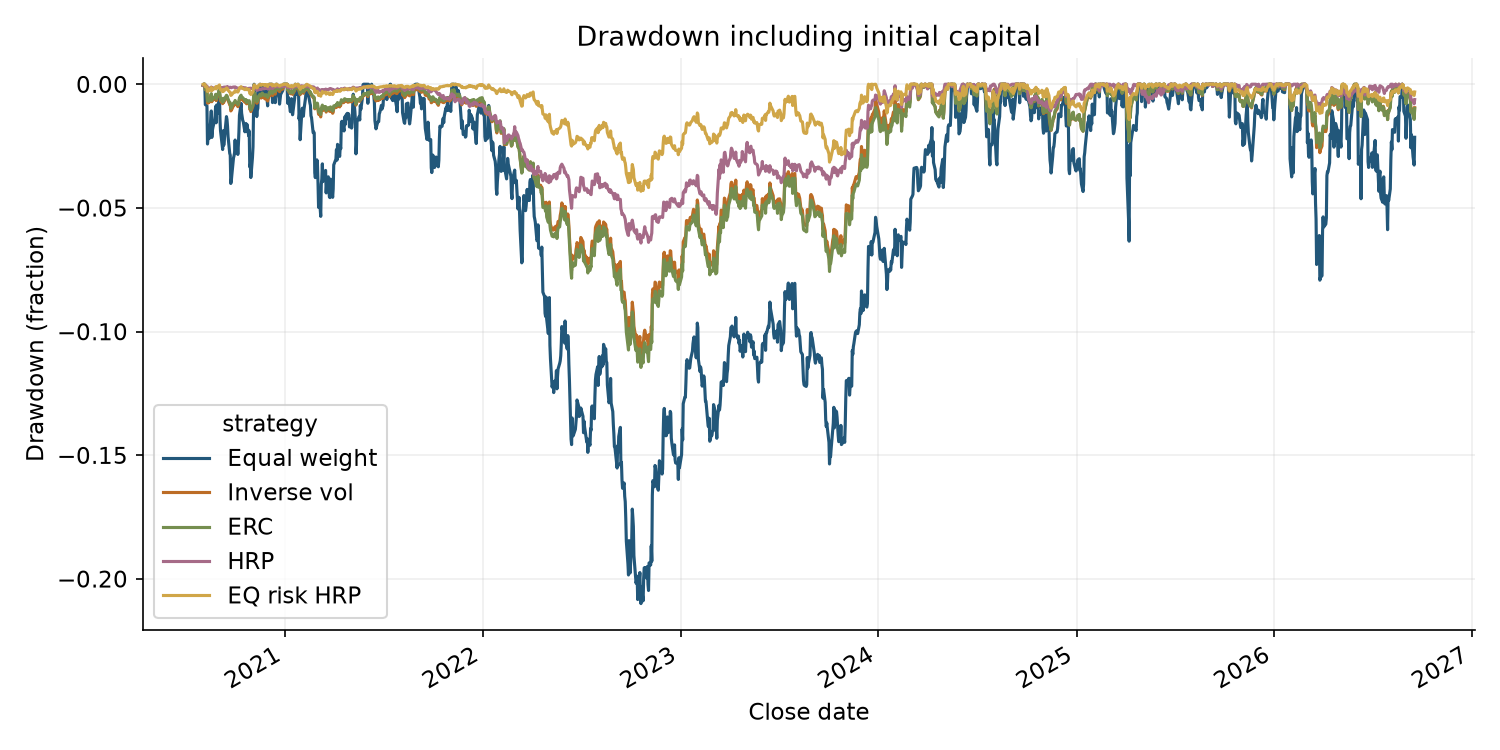

In [9]:
display(Image(filename=str(FIGURES / "drawdown.png")))

### Exposures

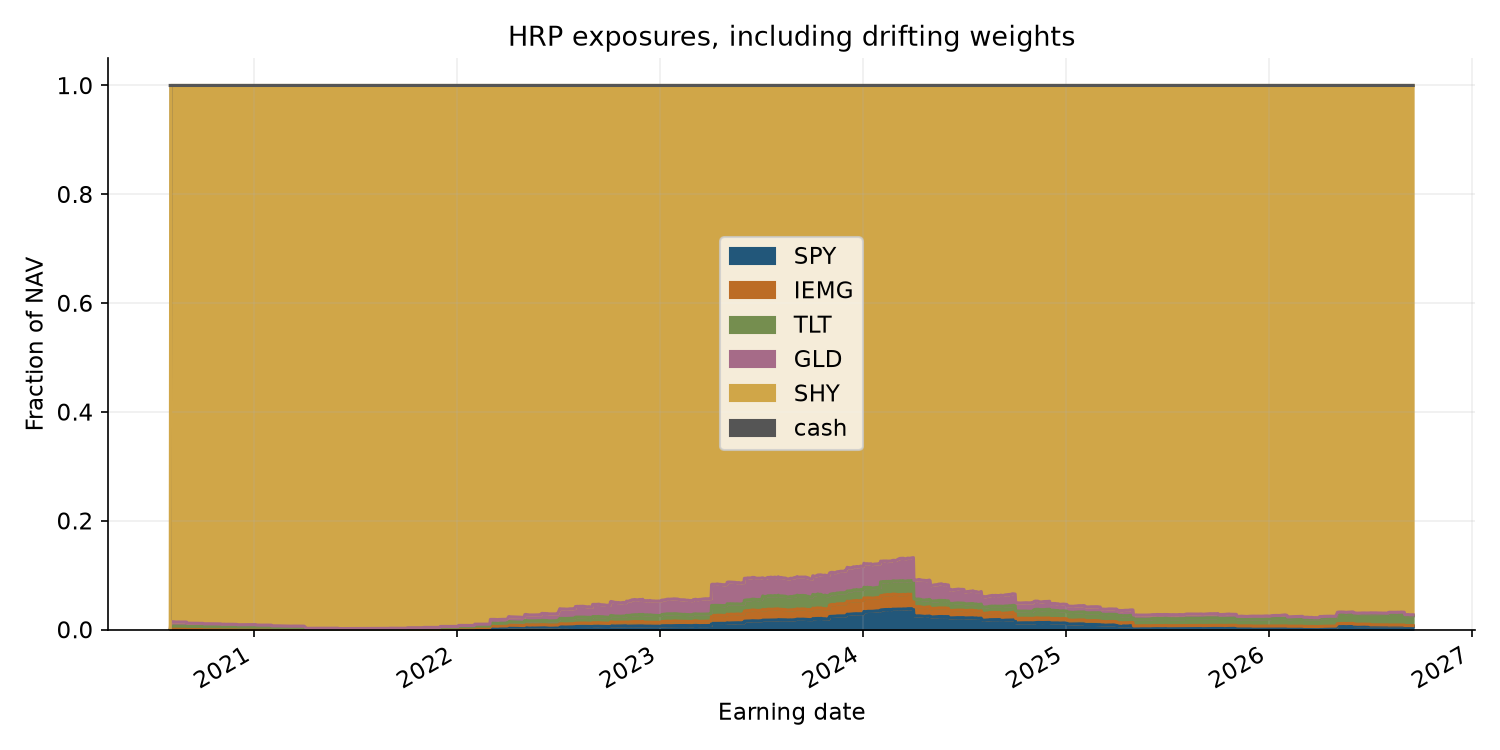

In [10]:
display(Image(filename=str(FIGURES / "exposures.png")))

### Incremental

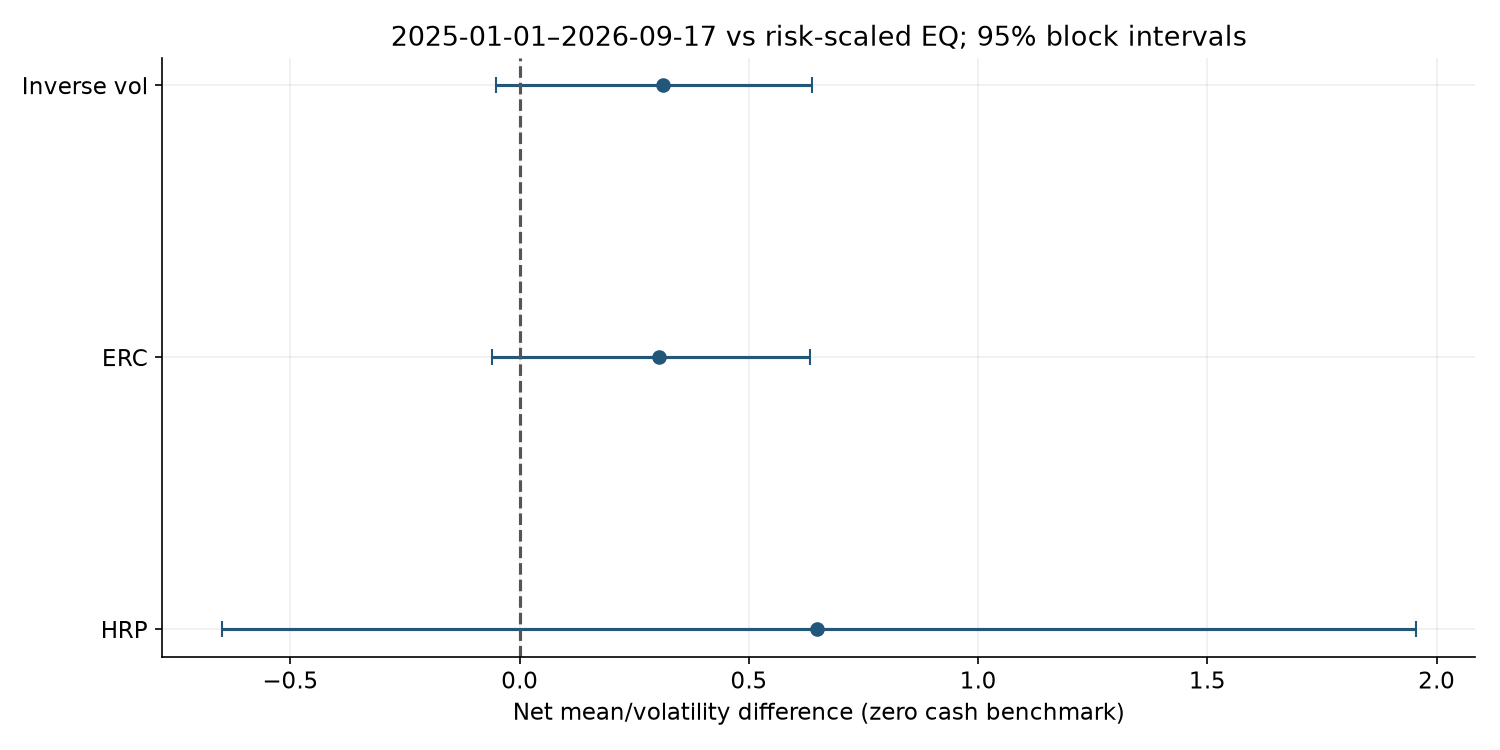

In [11]:
display(Image(filename=str(FIGURES / "incremental.png")))

## Calculation appendix

Independently reconstruct headline values and accounting identities from saved underlying outputs, then verify source/code/artifact hashes.

In [12]:
from research.check_artifacts import independent_checks
independent_checks()

Independent saved-output calculations and source/code hashes: passed


## Takeaways and next experiment

# Next research questions

The new [robust allocation chapters](../docs/robust-allocation.md) demonstrate estimation,
validation and selection mechanics. The following empirical extensions remain unrun.

1. **Freeze a bounded allocation family for future evaluation.** Record an economically
   justified universe, primary loss/comparator, training window, cap, stress set and all
   attempted alternatives before collecting a later uninspected sample. Keep the historical
   HRP specification separate; do not choose its best lookback from the sensitivity table.
2. **Separate stable decisions from low-risk concentration.** Apply joint block refits to
   rolling training windows, compare sample covariance with shrinkage and constrained rules,
   and report weight dispersion, concentration and risk-matched incremental outcomes. Include
   regime stresses beyond the finite scenarios illustrated in the teaching notebook.
3. **Make economic implementation realistic.** Pin observed cash yields, point-in-time
   instrument eligibility, distribution records and permitted vintage histories. Account for
   executable spreads, size and rebalancing capacity. Investigate how SHY exposure and cash
   accrual explain the existing ETF comparison.
4. **If adding predictive ML, validate its entire selection process.** Define label intervals
   and feature availability; fit preprocessing and tune parameters within training only.
   Assemble nested or combinatorial purged evaluation where justified, then check chronological
   deployment. The current split-mechanics notebook does not claim this pipeline exists.
5. **Preserve the full search record.** Retain failed trials and common-date return paths.
   Assess sensitivity to dependent trials and serially dependent observations before applying
   selection diagnostics to real allocation strategies. The historical record is incomplete
   for a defensible empirical DSR/PBO claim; synthetic examples do not fill that gap.

A VAA/DAA empirical replication needs its original eligible universes and validated signal
definitions. The current teaching chapters distinguish the ideas without claiming that
replication or promoting a new tactical winner.


See [source register](research/SOURCES.md), [audit](research/AUDIT.md), [protocol](research/PROTOCOL.md) and [publication review](PUBLICATION.md). No live publication is part of this build.